## Inside the heart of machine learning!

**Instructor**: Lisa-Marie Rolli, Volkamer Lab, Saarland University (lisa-marie.rolli@uni-saarland.de)


**Course date**: 2nd September 2026


Based on the notebook by Afnan Sultan.




### Important Note

If you're running this notebook on Google Colab, it will run a lot faster if you set the runtime type to **T4 GPU**.
You can do this from the **Runtime** menu.

Runtime->Change Runtime Type->T4 GPU

In [1]:
!pip install PyTDC
import torch
print(torch.__version__)
!pip install torch-geometric torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{torch.__version__}.html
# !pip install torch-geometric torch-scatter torch-sparse torch-cluster -f https://data.pyg.org/whl/torch-1.13.0+cu116.html

  Using cached pytdc-1.1.15.tar.gz (154 kB)
  Preparing metadata (setup.py) ... done
  Using cached accelerate-0.33.0-py3-none-any.whl.metadata (18 kB)
  Using cached dataclasses-0.6-py3-none-any.whl.metadata (3.0 kB)
  Using cached datasets-2.19.2-py3-none-any.whl.metadata (19 kB)
  Using cached evaluate-0.4.2-py3-none-any.whl.metadata (9.3 kB)
  Using cached fuzzywuzzy-0.18.0-py2.py3-none-any.whl.metadata (4.9 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached transformers-4.50.3-py3-none-any.whl.metadata (39 kB)
INFO: pip is looking at multiple versions of pytdc to determine which version is compatible with other requirements. This could take a while.
  Using cached pytdc-1.1.14.tar.gz (151 kB)
  Preparing metadata (setup.py) ... done
  Using cached scikit-learn-1.2.2.tar.gz (7.3 MB)
  Installing build dependencies ... done
  Getting require

2.11.0+cu128
Looking in links: https://data.pyg.org/whl/torch-2.11.0+cu128.html


# The most important aspect: Well-curated data
## Therapeutics Data Commons: An easily accessible source
- lots of standard data sets on [tdcommons.ai](https://tdcommons.ai)
- easy data splitting (random, scaffold, cold_*)

## A toxicity dataset: ToxCast
- made by [Richard, Ann M., et al. (2016)](https://pubmed.ncbi.nlm.nih.gov/27367298/)
- qualitative results of over 600 experiments on 8k compounds
- depends on various assays from couple hundres to thousands of drugs.
- highly imbalanced: for most assays there are more inactive than active compounds

In [17]:
from tdc.single_pred import Tox

# as ToxCast contains several assays, we have to specify the label_name
data = Tox(name = 'ToxCast', label_name = 'TOX21_AR_LUC_MDAKB2_Antagonist_0.5nM_R1881')
# today, we use a scaffold split
split = data.get_split(method='scaffold')
data.print_stats()

Found local copy...
Loading...
Done!
100%|██████████| 7931/7931 [00:03<00:00, 2090.87it/s]
--- Dataset Statistics ---
7931 unique drugs.
--------------------------


In [18]:
split['train']

,Drug_ID,Drug,Y
0,Drug 1,C[SiH](C)O[Si](C)(C)O[Si](C)(C)O[SiH](C)C,0.0
1,Drug 18,O=[N+]([O-])[O-].O=[N+]([O-])[O-].[Ba+2],0.0
2,Drug 20,Cl[Nd](Cl)Cl,0.0
3,Drug 22,Cl[Dy](Cl)Cl,0.0
4,Drug 23,Cl[In](Cl)Cl,0.0
...,...,...,...
5546,Drug 3344,Cl.c1ccc(CN(CC2=NCCN2)c2ccccc2)cc1,0.0
5547,Drug 7763,CN1C(=O)CC(c2ccccc2)C1=O,0.0
5548,Drug 7224,CN1C(=O)CC(C)(c2ccccc2)C1=O,0.0
5549,Drug 2783,CC(C)Oc1cc(-n2nc(C(C)(C)C)oc2=O)c(Cl)cc1Cl,1.0


### Label distribution

We plot the number of active (1) and inactive (0) compounds to see how imbalanced our dataset is. Below we can see barplot with the results for our selected assay.

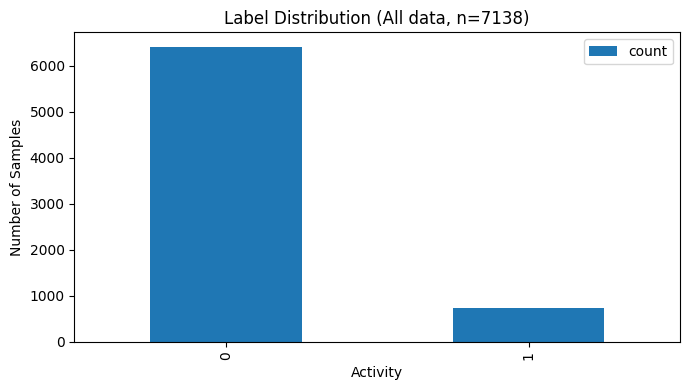

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# concatenate train + test into one Series
y_all = pd.concat([split['train']['Y'], split['test']['Y']]).dropna().astype(int)

fig, ax = plt.subplots(figsize=(7,4))


y_all.value_counts().sort_index().plot.bar()

# labels and title
ax.set_xlabel("Activity")
ax.set_ylabel("Number of Samples")
ax.set_title(f"Label Distribution (All data, n={len(y_all)})")
ax.legend()

plt.tight_layout()
plt.show()


# Featurization - The model doesn't see a molecule, it sees a *representation* of a molecule!
- __rdkit__ is the main tool for working with molecules
- `rdFingerprintGenerator` can  produce a multitude of fingerprints.
- We use the Morgan fingerprint approach to represet our molecules as a bit vector `GetMorganFingerprintAsBitVect`

## But... what exactly is this representation, and how it is generated?

- It's a way to convert a molecule into a binary vectors of 0s and 1s
- Each bit corresponds to an atom in an environment such as
  - Atomic number and connectivity/valence cues.
  - Hydrogen information
  - Formal charge.
  - Aromaticity flag.
  - Ring membership
  - Chirality (optional)
- The environment cues form a integer of 32 bits, and this integer is the identity of this atom in this environment[$^1$].
  - This id gets hashed to map to a single bit index in the bit vector.
    - The equation to get the bit index is `ìd % nBits`
- An activated bit (i.e., bit = 1), means that this atom in this environment is present in this molecule.
- The environment is defined circularly by choosing a radius to decide how many connecting atoms to consider
  - The radius is user defined
  - When using raius = n, the algorithm automatically calculates radius = 0, 0+1, 0+1+2, ... , 0+1+...+n-1+n
- The length of the vector is user defined
  - Longer vector = more environments to store.
    - But it also means that many bits will be zeros in most of the molecules because not all atom-environment pairs exist in all molecules (i.e., the vectors become sparse)

The below animation walks you through the construction of this algorithm.

Pay attention to bit at index 1 in the two molecules, and see when (and how many times) it gets activated.
- **Is it always the same atom-environment pair that activates it?**

Pay attention to index 1 in the Caffeine example
- **Does it get activated each time by the same atom-environment pair?**

---

[$^1$]: check this atom-enviroment coding for at `O` in an `O=C` environment.
- Number of non-hydrogen immediate neighbors = 3
- Valency minus the number of connected hydrogens = 4
- Atomic number = 6
- Atomic mass = 12
- Atomic charge = 0
- Number of attached hydrogens = 0
- Atom is a part of at least one ring = 0

`atom-environment pair ID = hash((3, 4, 6, 12, 0, 0, 0))`

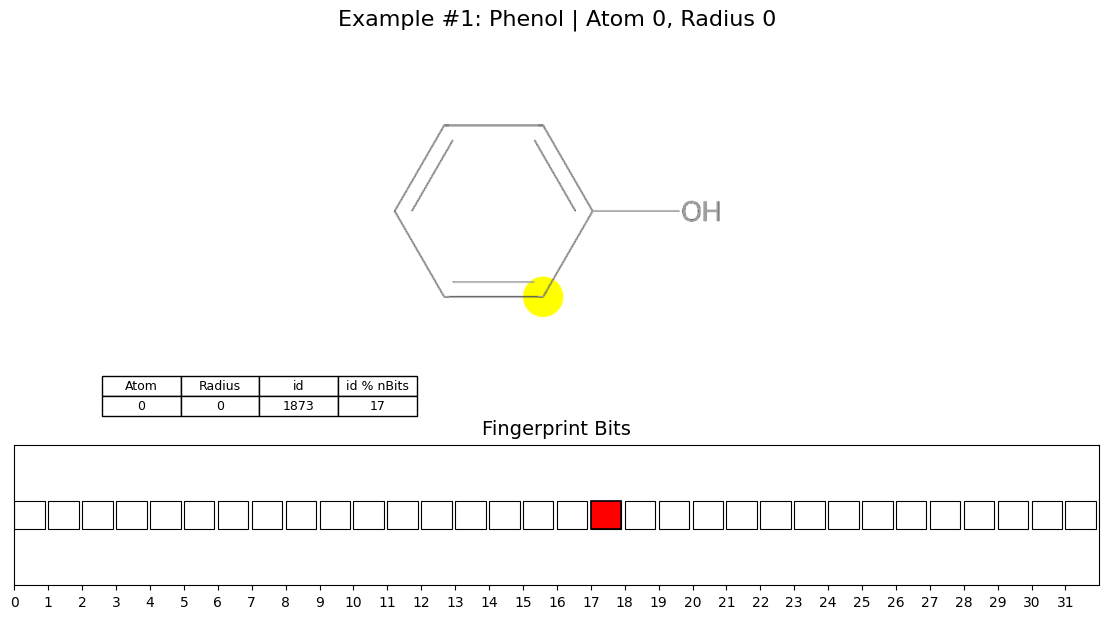

In [20]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.rdMolDescriptors import GetMorganFingerprintAsBitVect
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator, AdditionalOutput
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.animation import FuncAnimation
import numpy as np
import io
from PIL import Image as PilImage
from IPython.display import HTML

# --- Example molecules ---
examples = [
    ("Example #1: Phenol", "c1ccccc1O"),
    ("Example #2: Caffeine", "Cn1cnc2c1c(=O)n(c(=O)n2C)C")
]

# --- Parameters ---
radius = 2
nBits = 32
mfpgen_folded   = GetMorganGenerator(radius=radius, fpSize=nBits)  # folded
mfpgen_unfolded = GetMorganGenerator(radius=radius)                # unfolded

# --- Collect steps for all molecules ---
all_steps = []
for ex_id, (name, smi) in enumerate(examples):
    mol = Chem.MolFromSmiles(smi)
    AllChem.Compute2DCoords(mol)

    # folded bitInfo
    bitInfo = {}
    _ = GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nBits, bitInfo=bitInfo)

    # unfolded raw IDs
    info = AdditionalOutput()
    info.CollectBitInfoMap()
    _ = mfpgen_unfolded.GetFingerprint(mol, additionalOutput=info)
    bitInfoFull = info.GetBitInfoMap()  # raw env_id → [(atom_idx, rad), ...]

    for bit, infos in bitInfo.items():  # folded bits
        for atom_idx, rad in infos:
            env = Chem.FindAtomEnvironmentOfRadiusN(mol, rad, atom_idx)
            atoms = {atom_idx}
            for b in env:
                bond = mol.GetBondWithIdx(b)
                atoms.add(bond.GetBeginAtomIdx())
                atoms.add(bond.GetEndAtomIdx())

            # find raw env_id (32-bit)
            env_id = None
            for rid, tuples in bitInfoFull.items():
                for a, r in tuples:
                    if a == atom_idx and r == rad:
                        env_id = rid   # raw 32-bit env ID
                        break
                if env_id is not None:
                    break

            all_steps.append((ex_id, name, mol, rad, atom_idx, atoms, env, bit, env_id))

# sort: example first, then radius, then atom index
all_steps.sort(key=lambda x: (x[0], x[3], x[4]))

# ranges for reset per example
ex_ranges = {}
i = 0
while i < len(all_steps):
    ex_id = all_steps[i][0]
    j = i
    while j < len(all_steps) and all_steps[j][0] == ex_id:
        j += 1
    ex_ranges[ex_id] = (i, j)
    i = j

# --- Helper: draw molecule gray + highlight red ---
def mol_to_image_gray_base_with_highlight(mol, atoms=None, bonds=None, center_atom=None,
                                          size=(500, 500),
                                          gray_rgb=(160, 160, 160), black_thresh=40):
    m = Chem.Mol(mol)
    drawer = rdMolDraw2D.MolDraw2DCairo(size[0], size[1])
    opts = drawer.drawOptions()
    opts.padding = 0.02
    opts.bondLineWidth = 2
    if hasattr(opts, "useBWAtomPalette"):
        opts.useBWAtomPalette()

    atom_colors = {}
    if atoms:
        for a in atoms:
            if a == center_atom:
                atom_colors[a] = (1.0, 1.0, 0.0)   # yellow center atom
            else:
                atom_colors[a] = (1.0, 0.0, 0.0)   # red neighbors
    bond_colors = {b: (1.0, 0.0, 0.0) for b in (bonds or [])}

    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer, m,
        highlightAtoms=list(atoms) if atoms else [],
        highlightBonds=list(bonds) if bonds else [],
        highlightAtomColors=atom_colors,
        highlightBondColors=bond_colors,
    )
    drawer.FinishDrawing()
    img = PilImage.open(io.BytesIO(drawer.GetDrawingText())).convert("RGBA")

    arr = np.asarray(img).copy()
    rgb, alpha = arr[..., :3], arr[..., 3]
    near_black = (rgb[..., 0] < black_thresh) & (rgb[..., 1] < black_thresh) & \
                 (rgb[..., 2] < black_thresh) & (alpha > 0)
    arr[..., :3][near_black] = gray_rgb
    return PilImage.fromarray(arr, mode="RGBA")

# --- Fingerprint panel ---
def draw_fingerprint(ax, bit_array, highlight=None):
    ax.clear()
    ax.set_xlim(0, nBits)
    ax.set_ylim(0, 1)
    ax.set_xticks(range(nBits))
    ax.set_yticks([])
    ax.set_title("Fingerprint Bits", fontsize=14, pad=8)
    for i in range(nBits):
        color = "white" if bit_array[i] == 0 else "black"
        rect = Rectangle((i, 0.4), 0.9, 0.2, facecolor=color,
                         edgecolor="black", linewidth=0.8)
        ax.add_patch(rect)
    if highlight is not None:
        rect = Rectangle((highlight, 0.4), 0.9, 0.2, facecolor="red",
                         edgecolor="black", linewidth=1.2)
        ax.add_patch(rect)

# --- Animation setup ---
fig = plt.figure(figsize=(14, 7))
gs = fig.add_gridspec(2, 1, height_ratios=[2.5, 1])
ax_mol = fig.add_subplot(gs[0])
ax_fp  = fig.add_subplot(gs[1])

bit_array = np.zeros(nBits, dtype=int)

def update(frame):
    ex_id, ex_name, mol, rad, atom_idx, atoms, bonds, bit, env_id = all_steps[frame]

    # reset bits for this example only
    start, _ = ex_ranges[ex_id]
    bit_array[:] = 0
    for _, _, _, _, _, _, _, b, _ in all_steps[start:frame+1]:
        bit_array[b] = 1

    # clear mol panel
    ax_mol.clear()
    img = mol_to_image_gray_base_with_highlight(mol, atoms=atoms,
                                                bonds=bonds, center_atom=atom_idx,
                                                size=(500, 500))
    ax_mol.imshow(img)
    ax_mol.axis("off")
    ax_mol.set_title(f"{ex_name} | Atom {atom_idx}, Radius {rad}", fontsize=16, pad=15)

    # small table to right of molecule
    ax_table = ax_mol.inset_axes([-0.8, -0.6, 0.9, 1.2])  # X, y, width, height
    ax_table.axis("off")
    table_data = [[atom_idx, rad, env_id, env_id % nBits]]
    table = ax_table.table(cellText=table_data,
                           colLabels=["Atom", "Radius", "id", "id % nBits"],
                           loc="center", cellLoc="center")
    table.scale(1.0, 1.2)
    table.auto_set_font_size(False)
    table.set_fontsize(9)

    draw_fingerprint(ax_fp, bit_array, highlight=bit)

# --- Run animation ---
ani = FuncAnimation(fig, update, frames=len(all_steps), interval=1500, repeat=False)
HTML(ani.to_jshtml())


In [21]:
from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem

# Quiet rdkit warnings
RDLogger.logger().setLevel(RDLogger.CRITICAL)

In [22]:
from rdkit.Chem import rdFingerprintGenerator
# --- setup Morgan generator ---
nBits = 1024
radius = 2
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=nBits)

## Data splitting

We need to split our data into train and test sets so that we have some molecules to test our model on once finished training.

Today we use a scaffold splitting approach, which assignes molecules to train and test sets with a ratio of 80:20 so that compounds with the same scaffold will be assigned to the same set to avoid similarity bias.

We use the 80% to train the model, and the 20% to test it.

In [23]:
import numpy as np
import tqdm

smiles2fp = lambda smiles: mfpgen.GetFingerprintAsNumPy(Chem.MolFromSmiles(smiles))
X_train = np.stack(list(map(smiles2fp, tqdm.tqdm(split['train']['Drug']))))
y_train = split['train']['Y'].values
X_test = np.stack(list(map(smiles2fp, tqdm.tqdm(split['test']['Drug']))))
y_test = split['test']['Y'].values

100%|██████████| 1587/1587 [00:00<00:00, 4118.57it/s]


## Looking deeper into our representation

One thing we can do as an explorative analysis, is to briefly see what the model sees.

Currently, the `X_train` variable is just a vector of 0s and 1s.

We retrieve the meta data of each bit (i.e., the environment) and we use the molecular graph of the molecules to construct the substructure encoded in each bit.

In [24]:
# --- build list of molecules from SMILES ---
smiles_list = split['train']['Drug'].tolist()
mols = [Chem.MolFromSmiles(smi) for smi in smiles_list]

# --- collect bitInfo for each mol ---
bitinfos = []
for mol in mols:
    info = {}
    # radius must match your fingerprint generator (e.g. 2 for Morgan radius=2)
    _ = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius=2,
        nBits=X_train.shape[1],
        bitInfo=info
    )
    bitinfos.append(info)

### 1- How frequent are the bits?

The below figure show the percentage of molecules that activated a given bit.

There are a few bits that were activated in over 50% of the molecules, but the majority of the bits were active in less than 10% only.

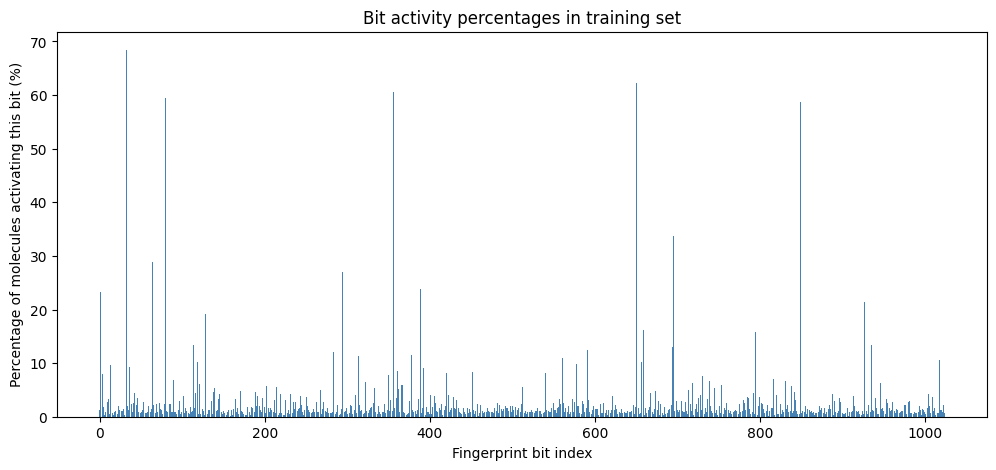

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Count number of molecules where each bit is active
bit_counts = X_train.sum(axis=0)   # shape: (n_bits,)
n_mols = X_train.shape[0]

# Convert to percentages
bit_percents = (bit_counts / n_mols) * 100

plt.figure(figsize=(12,5))
plt.bar(np.arange(len(bit_percents)), bit_percents, color="steelblue")
plt.xlabel("Fingerprint bit index")
plt.ylabel("Percentage of molecules activating this bit (%)")
plt.title("Bit activity percentages in training set")
plt.show()


### 2- What about collisions?

Collisions happen when the encoding of an atom and its environment ends up in the same bit as another atom and environment.

--

Two atom-environment pairs can map to the same bit **artifitially** as the way to assing an atom-environment identifier (id) to a bit is by getting the mod of `id % nBits` (see the animation).

Thus, two ids when divided by the vector length, can yeild the same mod.

For example, assume we have these two atom-environment pairs identifiers
<br>id1 = 123456
<br>id2 = 124480

id2 % 1024 = 960
<br>id2 % 1024 = 960

Both pair activate bit index 960.

--

But two atom-environment pair can lead to the same bit because they got the same identifier. And this happens when the two pairs are **chemically similar** that their environment infomation led to the same id.

--

The left plot below looks at each molecule and checks how many atom-environment pairs map to the same bit, and whether it is an artificial collision or chemical collision.

The right plot looks at the bits and see how many molecules showed this mapping for this bit, as well as the type of mapping (i.e., artifitial or chemicaly similar).

Avg chemical duplicates per molecule: 3.55
Avg artificial collisions per molecule: 1.31


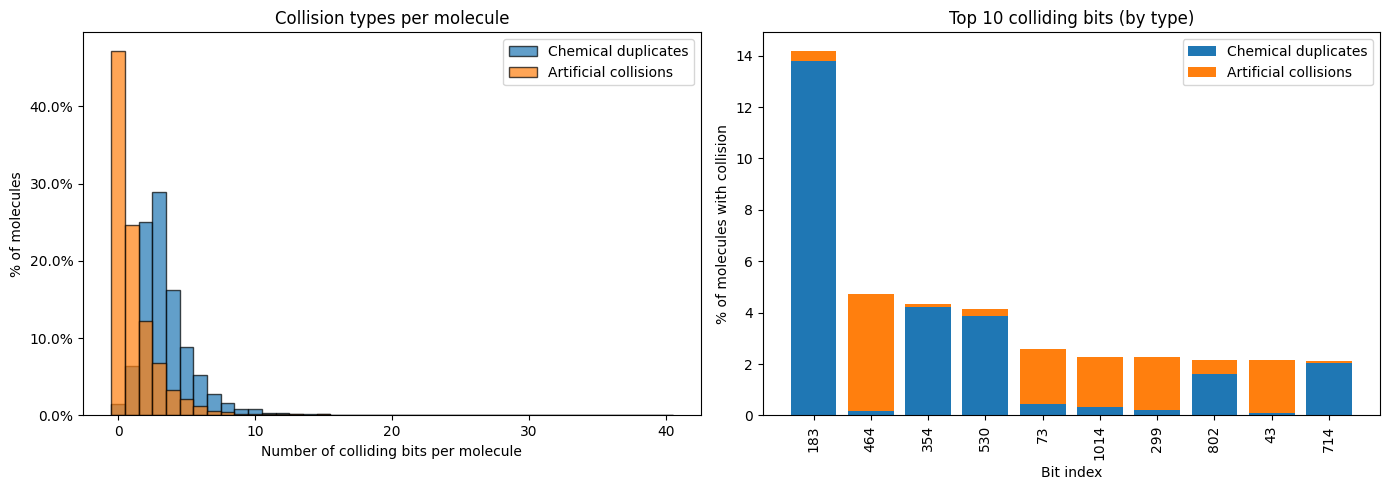

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from collections import defaultdict, Counter
import hashlib
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

def get_morgan_env_ids(mol, radius=2, nBits=1024):
    """
    Compute raw 32-bit IDs and folded IDs for all atom environments.
    Returns a list of (raw_id, folded_id, atom_idx, radius).
    """
    env_ids = []
    invariants = rdMolDescriptors.GetConnectivityInvariants(mol)

    for atom_idx in range(mol.GetNumAtoms()):
        for rad in range(radius + 1):
            env = Chem.FindAtomEnvironmentOfRadiusN(mol, rad, atom_idx)
            atoms = {atom_idx}
            for b in env:
                bond = mol.GetBondWithIdx(b)
                atoms.add(bond.GetBeginAtomIdx())
                atoms.add(bond.GetEndAtomIdx())

            # encode environment string
            env_string = ";".join(f"{a}:{invariants[a]}" for a in sorted(atoms)) \
                       + "|" + ",".join(str(b) for b in sorted(env))

            # SHA1 → 32-bit ID
            raw_id = int(hashlib.sha1(env_string.encode("utf-8")).hexdigest(), 16) & 0xFFFFFFFF
            folded_id = raw_id % nBits

            env_ids.append((raw_id, folded_id, atom_idx, rad))

    return env_ids

# --- Step 1: per-molecule collision classification ---
chem_counts, art_counts = [], []
chem_bit_counter, art_bit_counter = Counter(), Counter()

for smi in smiles_list:
    mol = Chem.MolFromSmiles(smi)
    env_ids = get_morgan_env_ids(mol, radius=2)  # from earlier helper
    folded_map = defaultdict(list)
    for raw_id, folded_id, atom_idx, rad in env_ids:
        folded_map[folded_id].append(raw_id)

    # classify per-molecule collisions
    c, a = 0, 0
    for bit, raws in folded_map.items():
        if len(raws) > 1:
            if len(set(raws)) == 1:
                c += 1
                chem_bit_counter[bit] += 1
            else:
                a += 1
                art_bit_counter[bit] += 1
    chem_counts.append(c)
    art_counts.append(a)

nMols = len(X_train)

print(f"Avg chemical duplicates per molecule: {np.mean(chem_counts):.2f}")
print(f"Avg artificial collisions per molecule: {np.mean(art_counts):.2f}")
nBits = 1024
# --- Step 2: per-bit percentages ---
chem_perc = {b: c/nMols*100 for b,c in chem_bit_counter.items()}
art_perc  = {b: c/nMols*100 for b,c in art_bit_counter.items()}
all_bits = set(chem_perc) | set(art_perc)
totals = {b: chem_perc.get(b,0)+art_perc.get(b,0) for b in all_bits}

# Top-k bits
k = 10
top_bits = sorted(totals, key=totals.get, reverse=True)[:k]
chem_vals = [chem_perc.get(b,0) for b in top_bits]
art_vals  = [art_perc.get(b,0) for b in top_bits]

# --- Step 3: plots ---
fig, axs = plt.subplots(1, 2, figsize=(14,5))

# (A) Histogram per molecule (collision type distribution)
all_counts = np.array(chem_counts + art_counts)
bins = np.arange(all_counts.min(), all_counts.max() + 2) - 0.5  # integer bins

axs[0].hist(chem_counts, bins=bins,
            weights=np.ones_like(chem_counts)*100.0/nMols,
            color="tab:blue", alpha=0.7, edgecolor="black", label="Chemical duplicates")
axs[0].hist(art_counts, bins=bins,
            weights=np.ones_like(art_counts)*100.0/nMols,
            color="tab:orange", alpha=0.7, edgecolor="black", label="Artificial collisions")

axs[0].set_xlabel("Number of colliding bits per molecule")
axs[0].set_ylabel("% of molecules")
axs[0].yaxis.set_major_formatter(PercentFormatter())
axs[0].set_title("Collision types per molecule")
axs[0].legend()

# (B) Top-k bits with stacked bars
x = np.arange(k)
top_idx = x
axs[1].bar(x, chem_vals, color="tab:blue", label="Chemical duplicates")
axs[1].bar(x, art_vals, bottom=chem_vals, color="tab:orange", label="Artificial collisions")
axs[1].set_xticks(x)
axs[1].set_xticklabels(top_bits, rotation=90)
axs[1].set_ylabel("% of molecules with collision")
axs[1].set_xlabel("Bit index")
axs[1].set_title(f"Top {k} colliding bits (by type)")
axs[1].legend()

plt.tight_layout()
plt.show()


### 3- How informative are the bits?

Now, each bit is activated in a group of molecules.

One can have a quick idea about the functionality of this bit by checking the toxicity distribution of the moelcules activated by it.

--

If these molecules have a the same label (i.e., small variance), then this bit is likely informative to predict toxicity.

--

In the below image, we see the most frquent bits in our dataset shown as the bars.

Then a second plot is overlayed that shows the mean and standard deviation of the molecules activated by this bit.

We can already see that the mean label is around 0, indicating that these bits might be associated with the negative class (inactive). Yet, due to the high class imbalance this analysis might be biased. The overall trend tells us that there seem to not be a single bit that gives us a lot of information immediately.

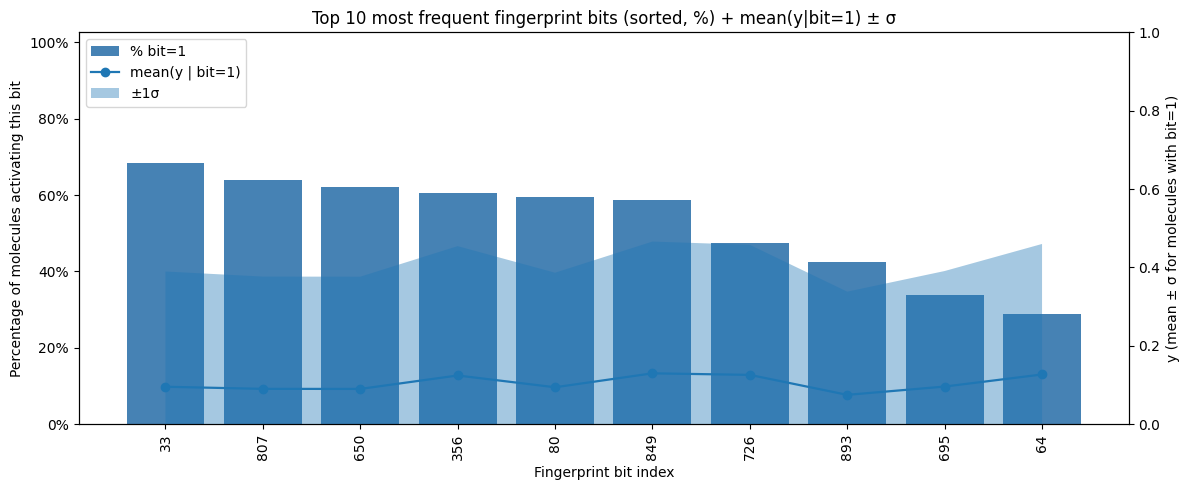

In [27]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np

# Count how many molecules activate each bit
bit_counts = X_train.sum(axis=0)
n_mols = X_train.shape[0]

# Top-k bits (same ranking since percentage = count / n_mols)
k = 10
top_idx = np.argsort(-bit_counts)[:k]
top_counts = bit_counts[top_idx]

# Sort descending for nice order
sorted_idx = np.argsort(-top_counts)
top_idx = top_idx[sorted_idx]
top_percents = (top_counts[sorted_idx] / n_mols) * 100

# ---- compute mean ± sigma of y for the "bit=1" group, in the same order ----
means_on = []
stds_on = []
for b in top_idx:
    mask = X_train[:, b].astype(bool)
    y_on = y_train[mask]
    if y_on.size == 0:
        means_on.append(np.nan)
        stds_on.append(np.nan)
    else:
        means_on.append(np.nanmean(y_on))
        # use ddof=1 for sample std if n>=2, else 0
        stds_on.append(np.nanstd(y_on, ddof=1) if y_on.size > 1 else 0.0)

means_on = np.array(means_on, dtype=float)
stds_on  = np.array(stds_on, dtype=float)

x = np.arange(k)

# ---- plot: bars (percent) on left axis + mean±sigma line on right axis ----
fig, ax1 = plt.subplots(figsize=(12,5))
bars = ax1.bar(x, top_percents, color="steelblue", label="% bit=1")
ax1.set_xticks(x)
ax1.set_xticklabels(top_idx, rotation=90)
ax1.set_xlabel("Fingerprint bit index")
ax1.set_ylabel("Percentage of molecules activating this bit")
ax1.yaxis.set_major_formatter(PercentFormatter())
ax1.set_title(f"Top {k} most frequent fingerprint bits (sorted, %) + mean(y|bit=1) ± σ")

# Secondary axis for continuous y
ax2 = ax1.twinx()
line, = ax2.plot(x, means_on, marker="o", linewidth=1.6, label="mean(y | bit=1)")
band = ax2.fill_between(x, means_on - stds_on, means_on + stds_on, alpha=0.4, label="±1σ")

ax2.set_ylabel("y (mean ± σ for molecules with bit=1)")

# Legends: combine handles from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper left")

# Add headroom so images/titles don’t collide (optional)
ymax_pct = top_percents.max() if top_percents.size else 0
ax1.set_ylim(0, ymax_pct * 1.5 if ymax_pct > 0 else 1)
ax2.set_ylim(0,1)
fig.tight_layout()
plt.show()


### 4- What are the bits?

Below we show the atom-environment pairs that have activated the different bits.

We show the most freuquent bits

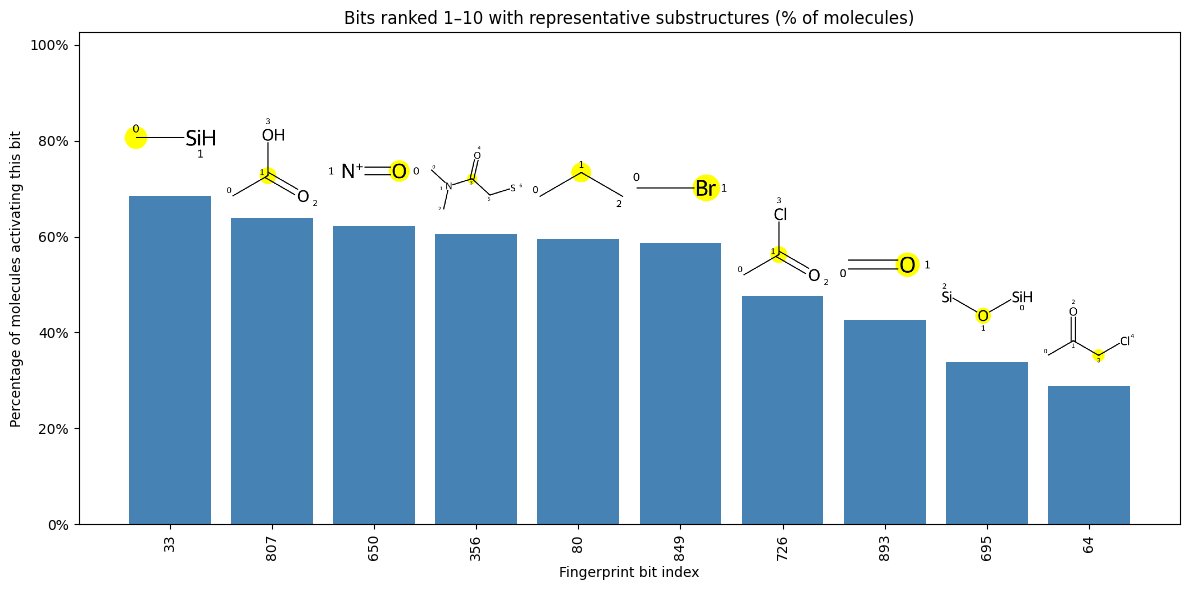

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
import io
from PIL import Image as PilImage

# --- Helper: convert RDKit Mol to PIL image with atom indices and highlight ---
def mol_to_img_with_highlight(mol, center_atom, size=(200,200)):
    drawer = rdMolDraw2D.MolDraw2DCairo(size[0], size[1])
    opts = drawer.drawOptions()
    opts.addAtomIndices = True
    opts.bondLineWidth = 2
    opts.padding = 0.05

    # make all atoms gray by default
    opts.useBWAtomPalette()

    # highlight center atom in bright yellow
    atom_colors = {center_atom: (1.0, 1.0, 0.0)}

    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer, mol, highlightAtoms=[center_atom], highlightAtomColors=atom_colors
    )
    drawer.FinishDrawing()
    return PilImage.open(io.BytesIO(drawer.GetDrawingText()))


# --- Helper: overlay molecule image above a bar ---
def add_mol_image(ax, mol, center_atom, x, y, zoom=0.4):
    if mol is None:
        return
    img = mol_to_img_with_highlight(mol, center_atom=center_atom, size=(180,180))
    im = OffsetImage(img, zoom=zoom)
    ab = AnnotationBbox(im, (x,y), frameon=False, xybox=(0,40),
                        xycoords='data', boxcoords="offset points", pad=0)
    ax.add_artist(ab)

# --- Main function: plot top-k bits with representative substructures ---
from matplotlib.ticker import PercentFormatter

def plot_bits_with_substructures(X, mols, bitinfos, start=0, k=10):
    n_mols = X.shape[0]
    bit_counts = X.sum(axis=0)

    # Rank all bits by frequency (descending)
    all_idx = np.argsort(-bit_counts)
    all_counts = bit_counts[all_idx]

    # Select window [start : start+k]
    top_idx = all_idx[start:start+k]
    top_counts = all_counts[start:start+k]
    top_percents = (top_counts / n_mols) * 100.0

    fig, ax = plt.subplots(figsize=(12,6))
    x = range(k)
    ax.bar(x, top_percents, color="steelblue")
    ax.set_xticks(x)
    ax.set_xticklabels(top_idx, rotation=90)
    ax.set_xlabel("Fingerprint bit index")
    ax.set_ylabel("Percentage of molecules activating this bit")
    ax.set_title(f"Bits ranked {start+1}–{start+k} with representative substructures (% of molecules)")
    ax.yaxis.set_major_formatter(PercentFormatter())

    if top_percents.max() < 1:
      from matplotlib.ticker import FuncFormatter
      ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v:.2f}".rstrip('0').rstrip('.') + '%'))
    # Increase y-limit for images
    ylim_max = (top_percents.max() if len(top_percents) else 0) * 1.5
    ax.set_ylim(0, ylim_max if ylim_max > 0 else 1)

    # Overlay substructure images at % heights
    for i, bit in enumerate(top_idx):
        for mol, info in zip(mols, bitinfos):
            if bit in info:
                atom_idx, rad = info[bit][0]
                env = Chem.FindAtomEnvironmentOfRadiusN(mol, rad, atom_idx)
                if not env:  # expand to radius=1 if empty
                    env = Chem.FindAtomEnvironmentOfRadiusN(mol, 1, atom_idx)
                atom_map = {}
                submol = Chem.PathToSubmol(mol, env, atomMap=atom_map)
                center_atom_submol = atom_map.get(atom_idx, 0)
                add_mol_image(ax, submol, center_atom=center_atom_submol, x=i, y=top_percents[i])
                break

    plt.tight_layout()
    plt.show()

# --- Usage ---
k = 10
plot_bits_with_substructures(X_train, mols, bitinfos, k=k)


And the least frequent bits

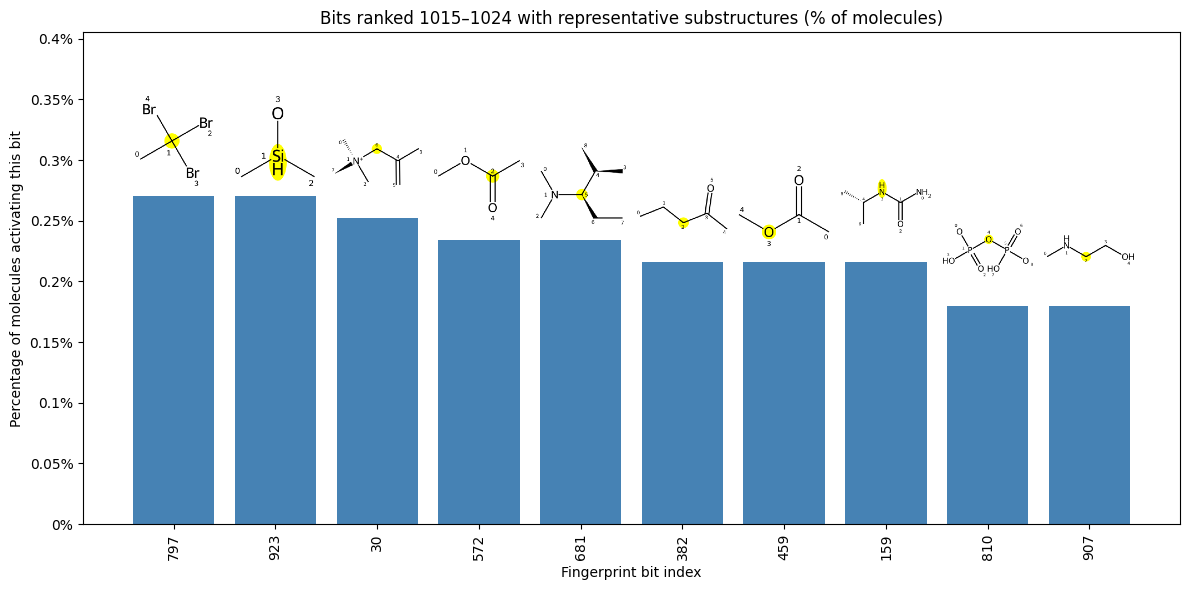

In [29]:
plot_bits_with_substructures(X_train, mols, bitinfos, start=nBits-k, k=k)

# Random forest classification

We have spent quite the time with the data and we have been seeing the molecular world by the eyes of our model.

Now, its time to give the space for our model to learn!

We will use a simple non-linear model that will try to figure out how to arrange, subset, and manouver these bits to make sensible predictions.

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import matthews_corrcoef, confusion_matrix, ConfusionMatrixDisplay

rf_model = RandomForestClassifier(n_estimators=500, max_depth = 20, min_samples_leaf = 15, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

mcc = matthews_corrcoef(y_test, y_pred)
con_matrix = confusion_matrix(y_test, y_pred)
print(f"Test (MCC): {mcc}")

Test (MCC): 0.21922331702854558


## Understanding the performance

Above, the Matthews Correlation Coefficient (MCC) is printed, and it is 0.22, indicating a modest performance.

Below, we show the confusion matrix



1.   The top one is the distributions of the predicted and the true values. And this plot shows that the model captured the width of the true value to some extent. But, it was more keen to make predictions at the center of the distribution.
2.   The bottom plot shows the alignment betwen predicitons and truth with varying metrics.
  - The pearson correlation (r) measures whether a model captured the trend in the data.
    - range = [-1, 1]
    - The higher the value the better.
    - Here, it is quite high (this is shown by the semi linear shape the scatter plot has)
  - The coeffecient of detemination ($R^2$) metric measures how much of the variance is explained.
    - Range = (-∞, 1]
    - The higher the value the better
    - Here, it is also a bit high (look at the distributions, they have quite a similar shape)
  - The mean absolute error (MAE) measures how far the predictions were from the truth regardless of the direction (i.e., doesn't matter if it over or under-predicts).
    - Range is data dependant
    - Interpretable by an endpoint expert






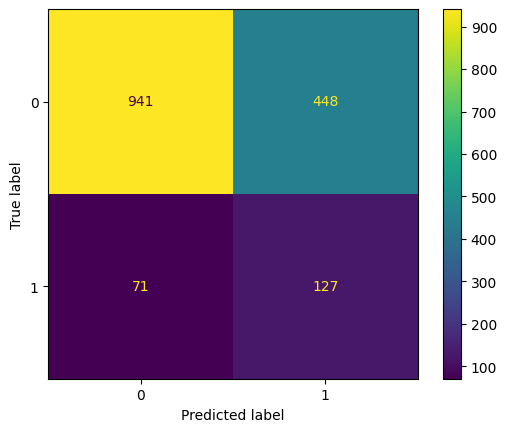

In [37]:

plt = ConfusionMatrixDisplay(con_matrix).plot()

## Interpreting the forest

The random forest algorithm is cool in the sense that it can assign an importance value for each bit.

This depends on how much each bit helped in reducing the variability in the data when used for splitting.

The below figure shows the most informative bits and displays their atom and environment as well for clarity.

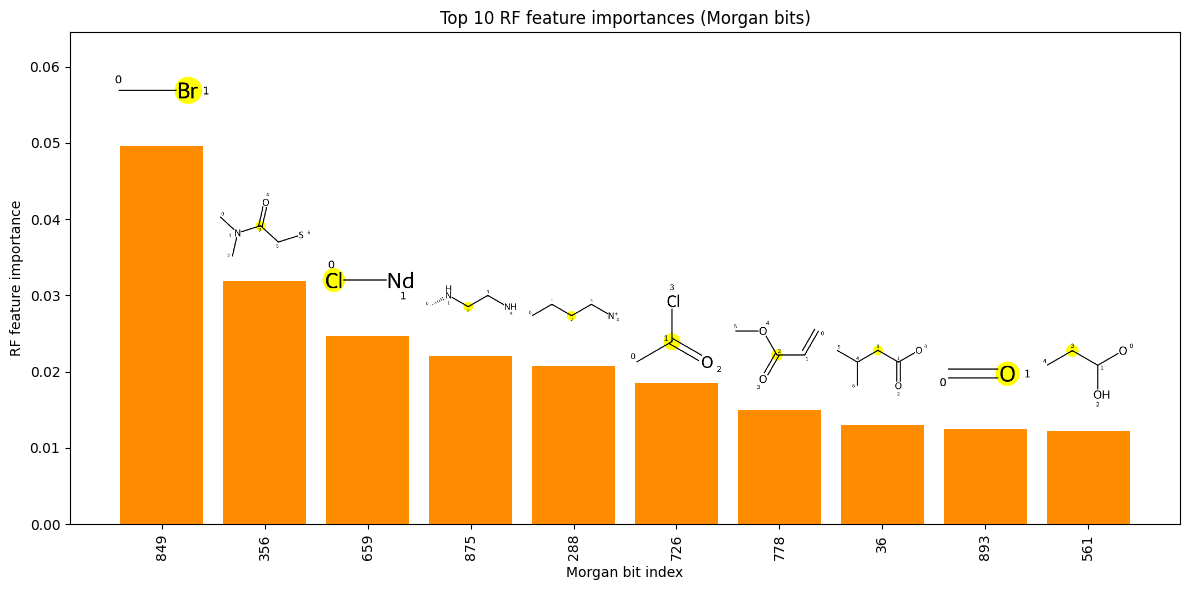

In [32]:
def plot_top_rf_bits_with_substructures(importances, bit_idx, mols, bitinfos, k=10):
    order = np.argsort(importances)[::-1]
    top_idx = order[:k]
    top_bits = bit_idx[top_idx]
    top_imps = importances[top_idx]

    fig, ax = plt.subplots(figsize=(12,6))
    x = range(k)
    ax.bar(x, top_imps, color="darkorange")
    ax.set_xticks(x)
    ax.set_xticklabels(top_bits, rotation=90)
    ax.set_xlabel("Morgan bit index")
    ax.set_ylabel("RF feature importance")
    ax.set_title(f"Top {k} RF feature importances (Morgan bits)")

    ylim_max = (top_imps.max() if len(top_imps) else 0) * 1.3
    ax.set_ylim(0, ylim_max if ylim_max > 0 else 1)

    # Try to overlay substructure images
    for i, bit in enumerate(top_bits):
        placed = False
        for mol, info in zip(mols, bitinfos):
            if bit in info:
                atom_idx, rad = info[bit][0]
                env = Chem.FindAtomEnvironmentOfRadiusN(mol, rad, atom_idx)
                if not env:  # fallback if lone atom
                    env = Chem.FindAtomEnvironmentOfRadiusN(mol, 1, atom_idx)

                atom_map = {}
                submol = Chem.PathToSubmol(mol, env, atomMap=atom_map)

                if atom_idx in atom_map:  # only highlight if mapping exists
                    center_atom_submol = atom_map[atom_idx]
                    add_mol_image(ax, submol, center_atom=center_atom_submol,
                                  x=i, y=top_imps[i])
                    placed = True
                    break
        if not placed:
            print(f"Skipping bit {bit} (could not map atom index)")

    plt.tight_layout()
    plt.show()


# --- Usage ---
importances = rf_model.feature_importances_
bit_idx = np.arange(X_train.shape[1])

plot_top_rf_bits_with_substructures(importances, bit_idx, mols, bitinfos, k=10)


# Closing the circle - going back to feature analysis

At the beginning, we spent quite the time looking at the data and seeing the world through the eyes of the model.

Is there direct mappings between the way we interpreted the world of th emodel, and the way the model intepreted it?

--

We already had a plot that showes the variance in class labels per activated bit. And we hoped to see some bits that would have particularly many active or inactive molecules, then they will be quite informaive ones.

But we did not really find many of such bits.

--

Now, the RF importance assignment is the equivelant of our variance analysis.

We can check whether there was any correlation betwen our thinking and the model's thinking.

The below plot shows for each bit the variance of the molecules that activated it vs. the imporntance assigned to it by the RF algorithm.

I would hope that bits with low variance correlate with high importance by the model.

--

And while the correlation did not show up. At least we see that the most informative features were more on the left side of the plot (i.e., the part with smaller variance)

Bits that are both high-importance and low-variance:
Empty DataFrame
Columns: [bit, importance_imp, variance_imp, importance_rank_imp, variance_rank_imp]
Index: []


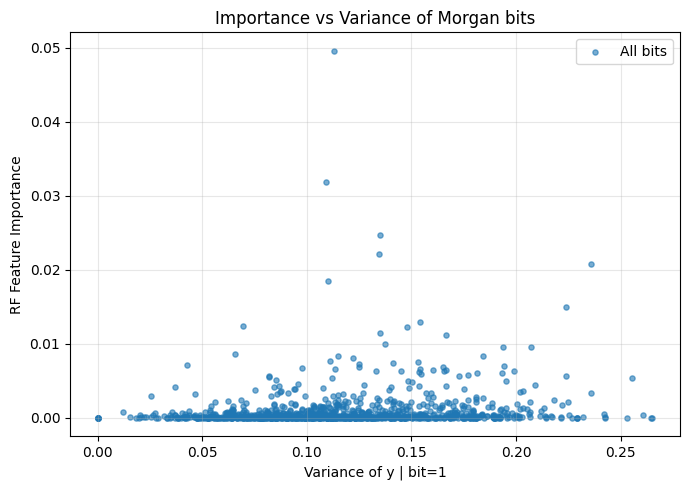

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: compute variance per bit ---
bit_variances = {}
for b in range(X_train.shape[1]):
    mask = X_train[:, b].astype(bool)
    y_on = y_train[mask]
    if y_on.size > 1:
        bit_variances[b] = np.var(y_on, ddof=1)   # sample variance
    else:
        bit_variances[b] = np.nan

# --- Step 2: collect into dataframe with importances ---
bit_idx = np.arange(X_train.shape[1])
importances = rf_model.feature_importances_

df = pd.DataFrame({
    "bit": bit_idx,
    "importance": importances,
    "variance": [bit_variances[b] for b in bit_idx]
}).dropna(subset=["variance"])

# --- Step 3: rank both dimensions ---
df["importance_rank"] = df["importance"].rank(ascending=False, method="min")
df["variance_rank"]   = df["variance"].rank(ascending=True, method="min")

# --- Step 4: define overlap sets ---
top_importance = df.nsmallest(20, "importance_rank")
low_variance   = df.nsmallest(20, "variance_rank")
intersection   = pd.merge(top_importance, low_variance, on="bit", suffixes=("_imp", "_var"))

print("Bits that are both high-importance and low-variance:")
print(intersection[["bit", "importance_imp", "variance_imp",
                    "importance_rank_imp", "variance_rank_imp"]])

# --- Step 5: scatter plot ---
plt.figure(figsize=(7,5))
plt.scatter(df["variance"], df["importance"], s=14, alpha=0.6, label="All bits")
if not intersection.empty:
    plt.scatter(intersection["variance"], intersection["importance"],
                color="red", s=40, label="Top importance & low variance")

plt.xlabel("Variance of y | bit=1")
plt.ylabel("RF Feature Importance")
plt.title("Importance vs Variance of Morgan bits")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Conclusion

In the lecture, you got exposed to many algorithms and models that one can pick and try. However, most of this notebook was about looking deeper at the steps of training a model including:
- Seeing the world through the eyes of the model
- Trying to anticipate in advance what is helpful and what is not
- Spending time and effort to contextualize the model's ouput through
  - Proper performance visualization
  - Interpretability analysis
  - Practicality lense
- Finally, going back to where we started to see how much were we accurate in our preliminary assumptions.

Using an ML library and training a model is an extremely simple thing nowadays.

But this is probably not the goal!

# More hands-on notebooks?

Check out the [TeachOpenCADD](https://volkamerlab.org/projects/teachopencadd/) collection from the Volkamer lab!
